# 02 — EDA

Explore the distribution of time-to-exploit and relationships between CVE characteristics and exploitation speed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/cve_master.csv', parse_dates=['nvd_published', 'kev_date_added'])
exploited = df[df['exploited'] == 1].copy()
print(f"Total: {len(df)} | Exploited: {len(exploited)}")

Total: 1371 | Exploited: 1371


## Distribution of days-to-exploit

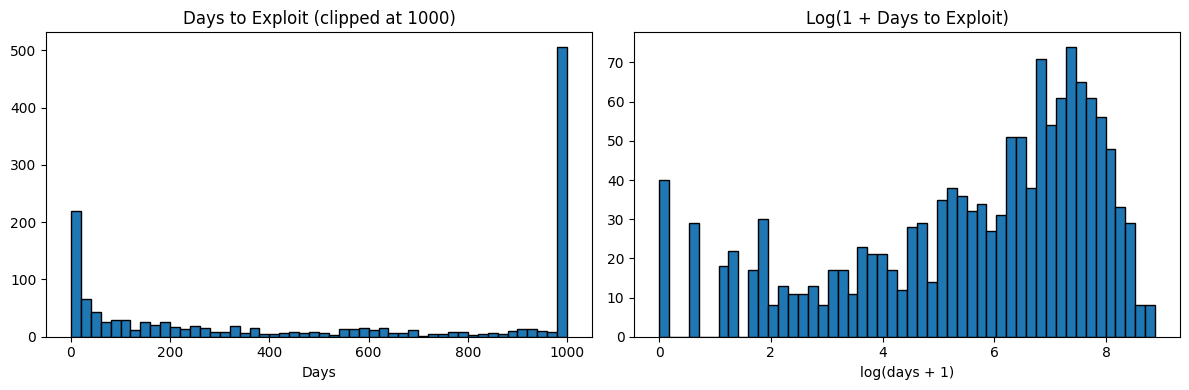

count    1371.000000
mean     1036.282276
std      1256.491550
min         0.000000
25%        69.000000
50%       559.000000
75%      1641.000000
max      7190.000000
Name: days_to_exploit, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(exploited['days_to_exploit'].clip(upper=1000), bins=50, edgecolor='black')
axes[0].set_title('Days to Exploit (clipped at 1000)')
axes[0].set_xlabel('Days')

axes[1].hist(np.log1p(exploited['days_to_exploit']), bins=50, edgecolor='black')
axes[1].set_title('Log(1 + Days to Exploit)')
axes[1].set_xlabel('log(days + 1)')

plt.tight_layout()
plt.show()

print(exploited['days_to_exploit'].describe())

## CVSS score vs. time-to-exploit

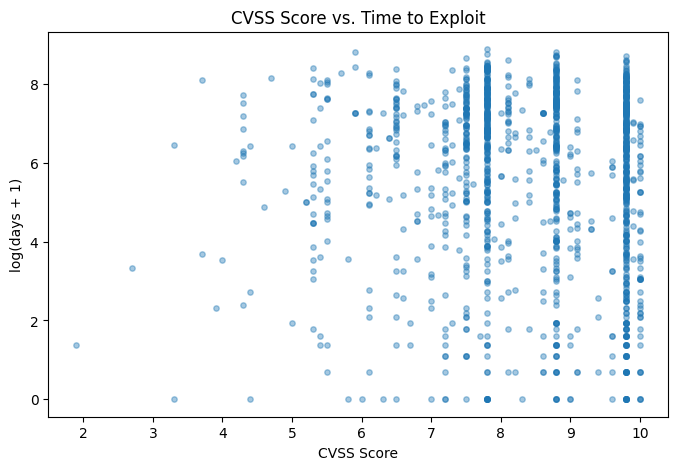

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(exploited['cvss_score'], np.log1p(exploited['days_to_exploit']), alpha=0.4, s=15)
ax.set_xlabel('CVSS Score')
ax.set_ylabel('log(days + 1)')
ax.set_title('CVSS Score vs. Time to Exploit')
plt.show()

## Time-to-exploit by severity tier

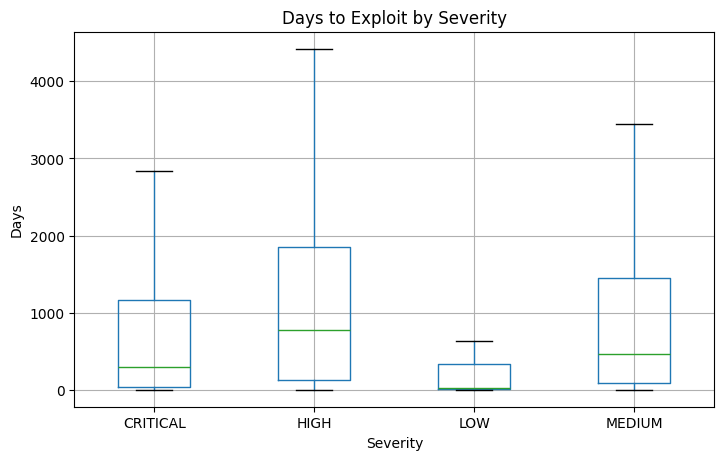

cvss_severity
LOW          27.0
MEDIUM      462.5
HIGH        768.0
CRITICAL    298.0
Name: days_to_exploit, dtype: float64

In [8]:
severity_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
sev_data = exploited[exploited['cvss_severity'].isin(severity_order)]

fig, ax = plt.subplots(figsize=(8, 5))
sev_data.boxplot(column='days_to_exploit', by='cvss_severity', ax=ax, showfliers=False)
ax.set_title('Days to Exploit by Severity')
ax.set_xlabel('Severity')
ax.set_ylabel('Days')
plt.suptitle('')
plt.show()

sev_data.groupby('cvss_severity')['days_to_exploit'].median().reindex(severity_order)

## Attack vector breakdown

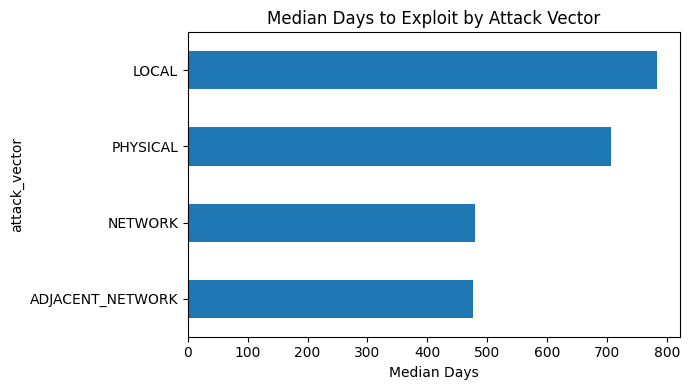

In [6]:
if 'attack_vector' in exploited.columns:
    av_medians = exploited.groupby('attack_vector')['days_to_exploit'].median().sort_values()
    av_medians.plot(kind='barh', figsize=(7, 4), title='Median Days to Exploit by Attack Vector')
    plt.xlabel('Median Days')
    plt.tight_layout()
    plt.show()

## EPSS score distribution

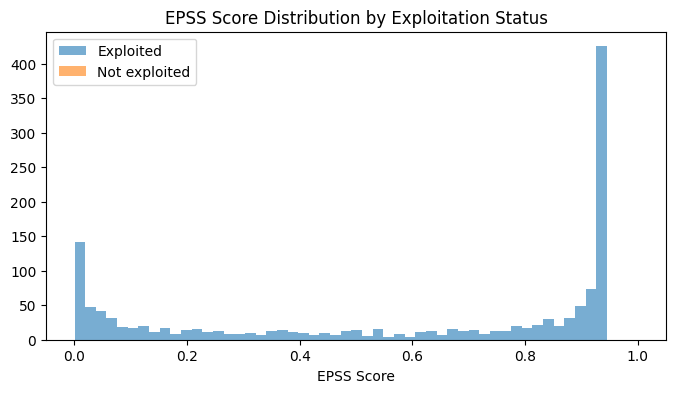

In [7]:
if 'epss_score' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(exploited['epss_score'].dropna(), bins=50, alpha=0.6, label='Exploited')
    ax.hist(df[df['exploited']==0]['epss_score'].dropna(), bins=50, alpha=0.6, label='Not exploited')
    ax.set_xlabel('EPSS Score')
    ax.set_title('EPSS Score Distribution by Exploitation Status')
    ax.legend()
    plt.show()